In [7]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import pandas as pd

import read_write_info
import experiment_global_vars
import os
import pickle
from math import sqrt
from scipy.stats import norm


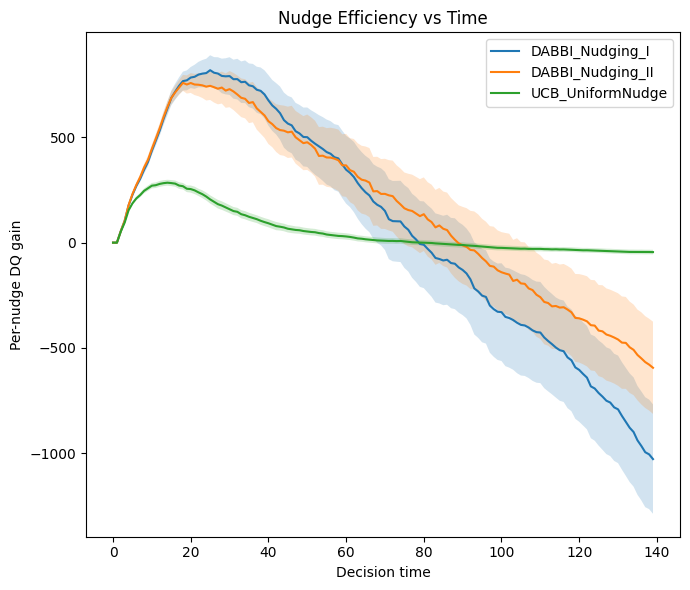

In [19]:
# plot efficiency gain versus time
from numpy import mean


base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_efficiency_tensor(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    eff = metrics.get('nudge_efficiency', None)
    if eff is None:
        raise ValueError(f"Missing 'nudge_efficiency' in {metrics_path}")
    return np.asarray(eff)  # [seed, user, time]

# def mean_and_ci_95(eff_tensor):
#     if eff_tensor.ndim != 3:
#         raise ValueError('Expected tensor of shape [seed, user, time]')
#     S, U, T = eff.shape
#     eff_flat = eff.reshape(S * U, T)       # [S*U, T]

#     mean_series = eff_flat.mean(axis=0)    # mean over all seed-user obs
#     std_pooled = eff_flat.std(axis=0, ddof=1)
#     sem_pooled = std_pooled / np.sqrt(S * U)

#     z_crit = norm.ppf(0.975)  # ~1.96
#     ci_95 = z_crit * sem_pooled


#     print("S, U, S*U:", S, U, S*U)
#     print("median SEM pooled:", np.median(sem_pooled))

#     # If you still have seed-only SEM, compare:
#     eff_seed_mean = eff.mean(axis=1)  # [S, T]
#     sem_seeds = eff_seed_mean.std(axis=0, ddof=1) / np.sqrt(S)
#     print("median SEM seeds:", np.median(sem_seeds))
#     return mean_series, ci_95

def mean_and_ci_95(eff_tensor):
    # eff: [S, U, T]
    S, U, T = eff_tensor.shape
    
    # Average users within each seed first -> [S, T]
    eff_seed_mean = eff_tensor.mean(axis=1)
    mean_series = eff_seed_mean.mean(axis=0)
    
    # SEM across seeds (treating seeds as independent)
    std_seeds = eff_seed_mean.std(axis=0, ddof=1)
    sem_seeds = std_seeds / np.sqrt(S)
    
    # 95% CI
    ci_95 = 1.96 * sem_seeds
    return mean_series, ci_95

# def mean_and_ci_95(eff_tensor):
#     # eff_tensor: [num_seeds, num_users, num_times]
#     import numpy as np
#     if eff_tensor.ndim != 3:
#         raise ValueError("Expected tensor of shape [seed, user, time]")

#     # Per-user mean across seeds -> [num_users, num_times]
#     eff_user_mean = eff_tensor.mean(axis=0)

#     # Overall mean across users -> [num_times]
#     mean_series = eff_user_mean.mean(axis=0)

#     # SEM across users -> [num_times]
#     num_users = eff_user_mean.shape[0]
#     if num_users <= 1:
#         ci_95 = np.zeros_like(mean_series)
#     else:
#         std_users = eff_user_mean.std(axis=0, ddof=1)
#         sem_users = std_users / np.sqrt(num_users)
#         ci_95 = 1.96 * sem_users

#     return mean_series, ci_95

plt.figure(figsize=(7, 6))
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    eff = load_efficiency_tensor(metrics_path)
    mean_series, sem_series = mean_and_ci_95(eff)
    t = np.arange(len(mean_series))
    plt.plot(t, mean_series, label=alg)
    plt.fill_between(t, mean_series - sem_series, mean_series + sem_series, alpha=0.2)

plt.xlabel('Decision time')
plt.ylabel('Per-nudge DQ gain')
plt.title('Nudge Efficiency vs Time')
plt.legend()
plt.tight_layout()
plt.show()

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...


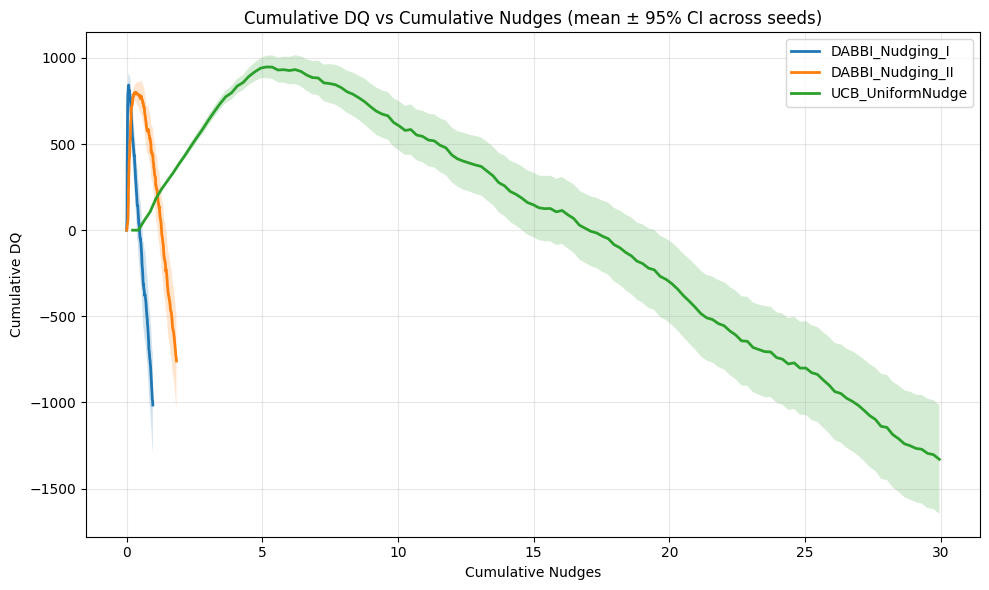

In [20]:
# plot cumulative DQ versus cumulative nudge

def load_cumulative_metrics(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    # Get cumulative DQ and nudges from metrics
    total_dq_cum = metrics.get('total_dq_cum', None)
    total_nudges_cum = metrics.get('total_nudges_cum', None)
    
    if total_dq_cum is None or total_nudges_cum is None:
        raise ValueError(f"Missing cumulative data in {metrics_path}")
    
    return np.array(total_dq_cum), np.array(total_nudges_cum)

def aggregate_cumulative_seed_level(dq_cum, nudges_cum):
    """Aggregate cumulative trajectories at seed level (across users)"""
    # dq_cum, nudges_cum: [num_seeds, num_users, num_times]
    S, U, T = dq_cum.shape
    
    # Average across users for each seed -> [num_seeds, num_times]
    dq_seed_mean = dq_cum.mean(axis=1)
    nudges_seed_mean = nudges_cum.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_dq = dq_seed_mean.mean(axis=0)
    mean_nudges = nudges_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = dq_seed_mean.shape[0]

    std_dq = dq_seed_mean.std(axis=0, ddof=1)
    std_nudges = nudges_seed_mean.std(axis=0, ddof=1)
    sem_dq = std_dq / np.sqrt(num_seeds)
    sem_nudges = std_nudges / np.sqrt(num_seeds)
    
    # 95% CI
    ci_dq = 1.96 * sem_dq
    ci_nudges = 1.96 * sem_nudges

    
    return mean_dq, mean_nudges, ci_dq, ci_nudges

def plot_cumulative_dq_vs_nudges(alg_data):
    plt.figure(figsize=(10, 6))
    
    for alg_name, (mean_dq, mean_nudges, ci_dq, ci_nudges) in alg_data.items():
        # Plot mean trajectory
        plt.plot(mean_nudges, mean_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        plt.fill_between(mean_nudges, 
                        mean_dq - ci_dq, 
                        mean_dq + ci_dq, 
                        alpha=0.2)
    
    plt.xlabel('Cumulative Nudges')
    plt.ylabel('Cumulative DQ')
    plt.title('Cumulative DQ vs Cumulative Nudges (mean ± 95% CI across seeds)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
    mean_dq, mean_nudges, ci_dq, ci_nudges = aggregate_cumulative_seed_level(dq_cum, nudges_cum)
    alg_data[alg] = (mean_dq, mean_nudges, ci_dq, ci_nudges)

plot_cumulative_dq_vs_nudges(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


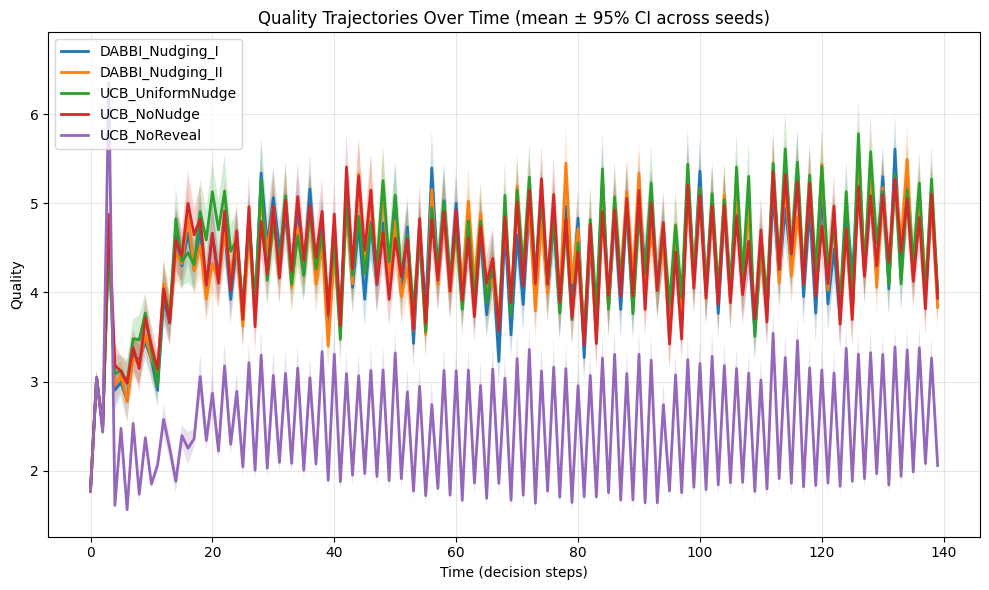

In [22]:
base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_quality_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    # Get quality trajectories from metrics
    quality_trajectories = metrics.get('quality_trajectories', None)
    
    if quality_trajectories is None:
        raise ValueError(f"Missing 'quality_trajectories' in {metrics_path}")
    
    return np.array(quality_trajectories)  # [num_seeds, num_users, num_times]

def aggregate_quality_seed_level(quality_tensor):
    """Aggregate quality trajectories at seed level (across users)"""
    # quality_tensor: [num_seeds, num_users, num_times]
    S, U, T = quality_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_times]
    quality_seed_mean = quality_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_quality = quality_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = quality_seed_mean.shape[0]

    std_quality = quality_seed_mean.std(axis=0, ddof=1)
    sem_quality = std_quality / np.sqrt(num_seeds)
    
    # 95% CI
    ci_quality = 1.96 * sem_quality

    
    return mean_quality, ci_quality

def plot_quality_trajectories(alg_data):
    plt.figure(figsize=(10, 6))
    
    for alg_name, (mean_quality, ci_quality) in alg_data.items():
        t = np.arange(len(mean_quality))
        
        # Plot mean trajectory
        plt.plot(t, mean_quality, label=alg_name, linewidth=2)
        
        # Add confidence bands
        plt.fill_between(t, 
                        mean_quality - ci_quality, 
                        mean_quality + ci_quality, 
                        alpha=0.2)
    
    plt.xlabel('Time (decision steps)')
    plt.ylabel('Quality')
    plt.title('Quality Trajectories Over Time (mean ± 95% CI across seeds)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    quality_tensor = load_quality_trajectories(metrics_path)
    mean_quality, ci_quality = aggregate_quality_seed_level(quality_tensor)
    alg_data[alg] = (mean_quality, ci_quality)

plot_quality_trajectories(alg_data)

In [ ]:
base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_nudge_rates_vs_tau(alg_data):
    plt.figure(figsize=(10, 6))
    
    # Tau bin labels
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))
    
    for alg_name, (mean_nudge_rate, ci_nudge_rate) in alg_data.items():
        plt.plot(x_pos, mean_nudge_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        plt.errorbar(x_pos, mean_nudge_rate, yerr=ci_nudge_rate, 
                    capsize=5, capthick=2, alpha=0.7)
    
    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Nudge Rate')
    plt.title('Nudge Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    nudge_rate_tensor = load_metrics(metrics_path, 'nudge_rate_by_tau')
    mean_nudge_rate, ci_nudge_rate = aggregate_seed_level(nudge_rate_tensor)
    alg_data[alg] = (mean_nudge_rate, ci_nudge_rate)

plot_nudge_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...


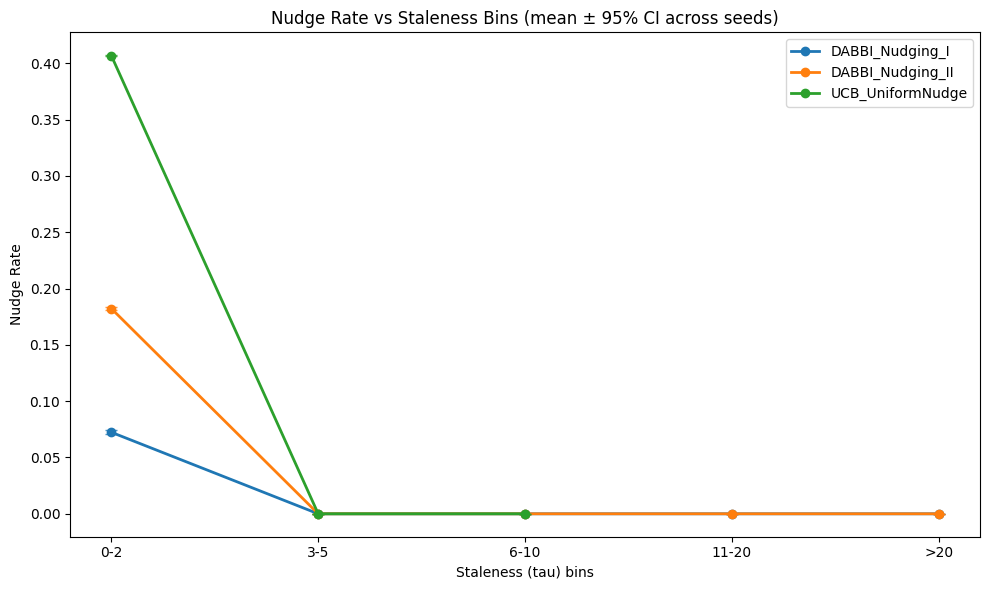

In [25]:
base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_nudge_rates_vs_tau(alg_data):
    import matplotlib.pyplot as plt
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_rate, ci_rate) in alg_data.items():
        line, = plt.plot(x_pos, mean_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_rate, yerr=ci_rate, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Nudge Rate')
    plt.title('Nudge Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.tight_layout()
    plt.show()
# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    nudge_rate_tensor = load_metrics(metrics_path, 'nudge_rate_by_tau')
    mean_nudge_rate, ci_nudge_rate = aggregate_seed_level(nudge_rate_tensor)
    alg_data[alg] = (mean_nudge_rate, ci_nudge_rate)

plot_nudge_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


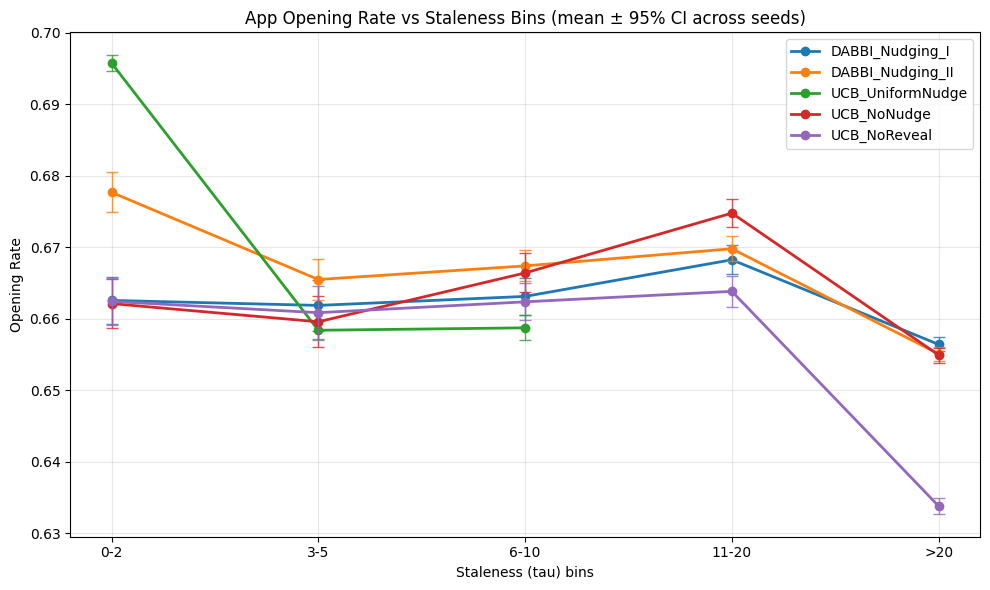

In [27]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_open_rates_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_rate, ci_rate) in alg_data.items():
        line, = plt.plot(x_pos, mean_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_rate, yerr=ci_rate, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Opening Rate')
    plt.title('App Opening Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    open_rate_tensor = load_metrics(metrics_path, 'open_rate_by_tau')
    mean_open_rate, ci_open_rate = aggregate_seed_level(open_rate_tensor)
    alg_data[alg] = (mean_open_rate, ci_open_rate)

plot_open_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


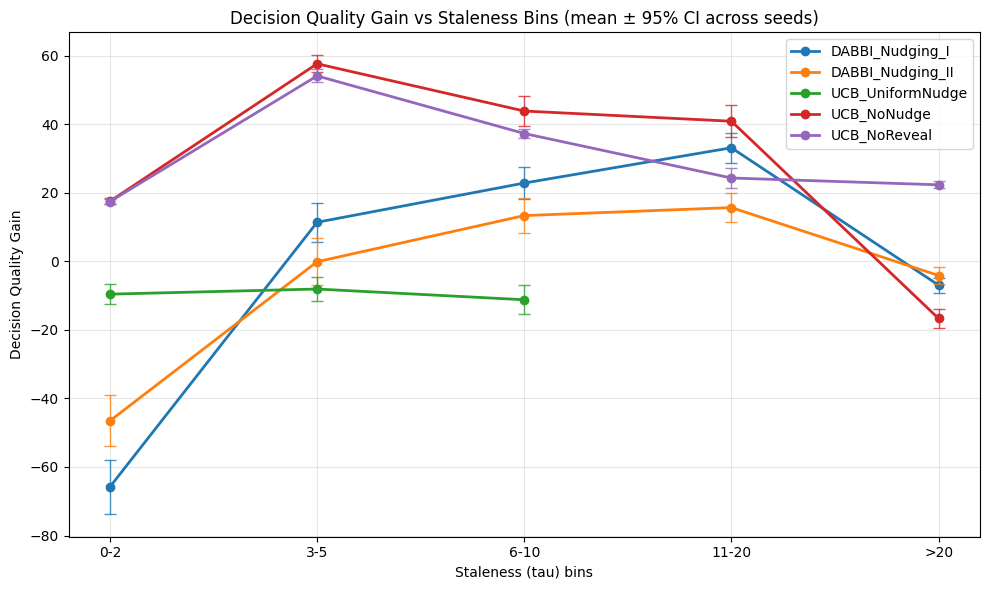

In [31]:
import os, pickle, numpy as np
import matplotlib.pyplot as plt

base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_dq_gain_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_dq, ci_dq) in alg_data.items():
        line, = plt.plot(x_pos, mean_dq, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_dq, yerr=ci_dq, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Decision Quality Gain')
    plt.title('Decision Quality Gain vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    dq_gain_tensor = load_metrics(metrics_path, 'dq_gain_by_tau')
    mean_dq_gain, ci_dq_gain = aggregate_seed_level(dq_gain_tensor)
    alg_data[alg] = (mean_dq_gain, ci_dq_gain)

plot_dq_gain_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


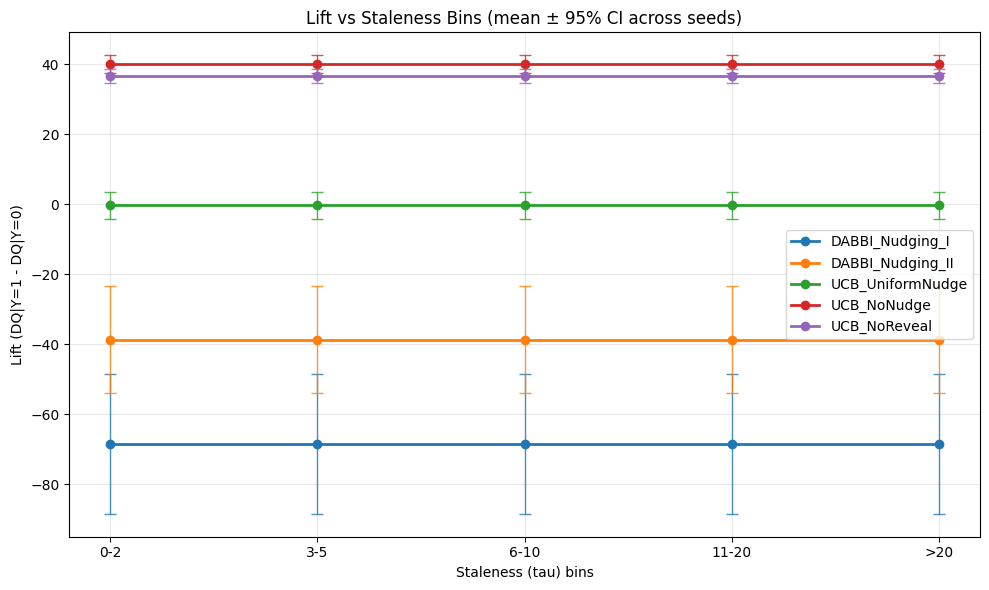

In [32]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_lift_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_lift, ci_lift) in alg_data.items():
        line, = plt.plot(x_pos, mean_lift, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_lift, yerr=ci_lift, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Lift (DQ|Y=1 - DQ|Y=0)')
    plt.title('Lift vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    lift_tensor = load_metrics(metrics_path, 'dq_lift_by_tau')
    mean_lift, ci_lift = aggregate_seed_level(lift_tensor)
    alg_data[alg] = (mean_lift, ci_lift)

plot_lift_vs_tau(alg_data)

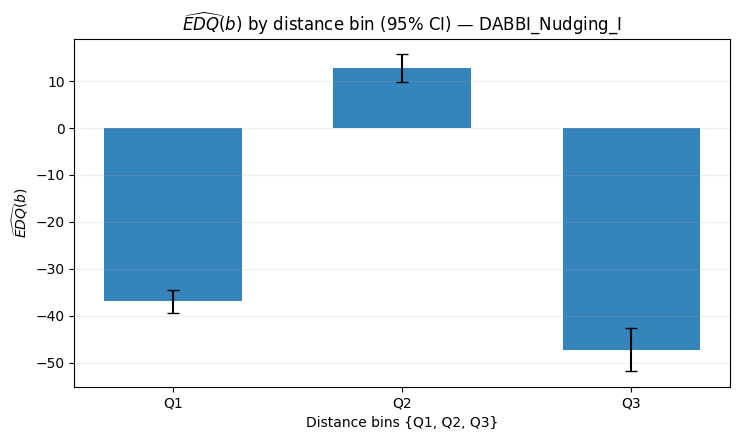

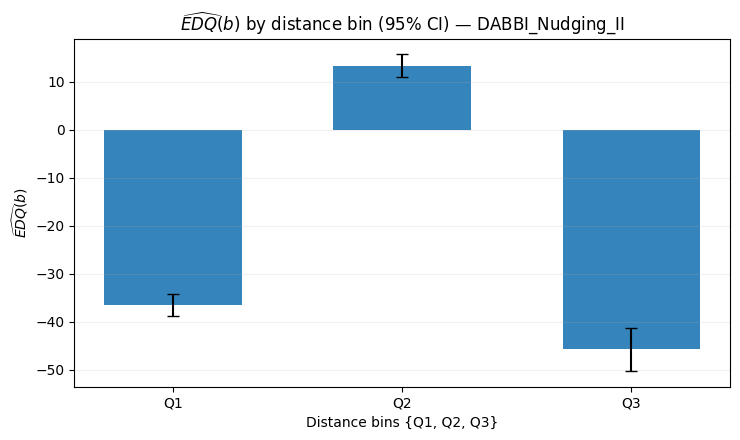

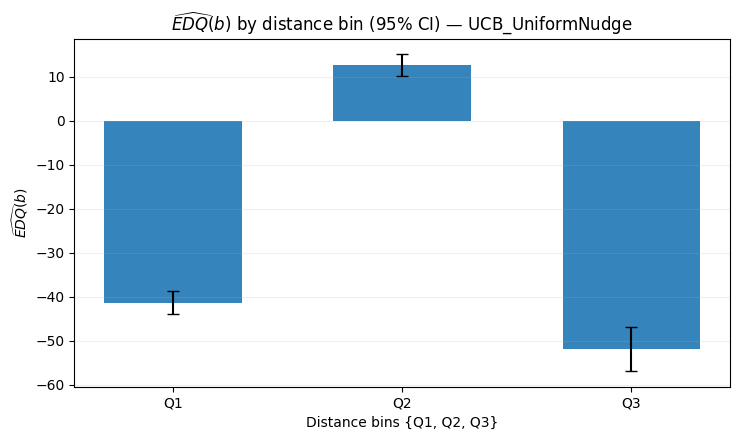

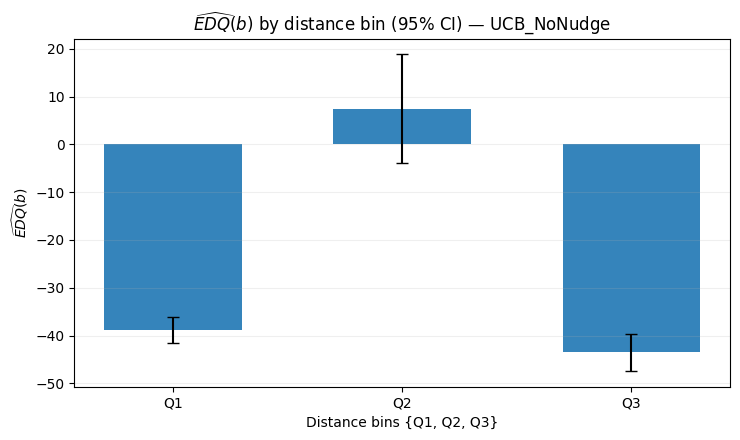

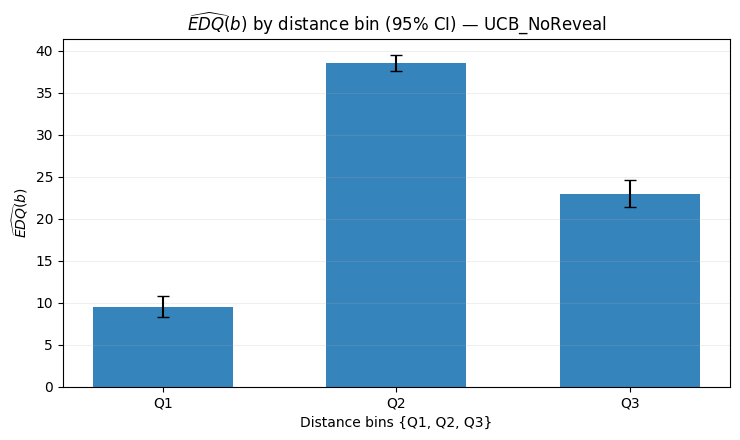

In [34]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_action_disagreement(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    ad = metrics.get('action_disagreement', None)
    if ad is None or not all(k in ad for k in ['EDQ','p_Y','VPN','bin_names']):
        raise ValueError(f"Missing action_disagreement in {metrics_path}")
    return np.asarray(ad['EDQ']), ad['bin_names']  # EDQ: [seed, user, bin]

def aggregate_seed_level_edq(edq_tensor):
    # edq_tensor: [S, U, B]
    seed_means = edq_tensor.mean(axis=1)          # [S, B] mean over users within seed
    mean_bins  = seed_means.mean(axis=0)          # [B]   mean over seeds
    S = seed_means.shape[0]
    if S > 1:
        std_bins = seed_means.std(axis=0, ddof=1)
        sem_bins = std_bins / np.sqrt(S)
        ci95_bins = 1.96 * sem_bins
    else:
        ci95_bins = np.zeros_like(mean_bins)
    return mean_bins, ci95_bins

def plot_edq_bars(mean_edq, ci_edq, bin_names, title_suffix=''):
    x = np.arange(len(bin_names))
    plt.figure(figsize=(7.5, 4.5))
    plt.bar(x, mean_edq, yerr=ci_edq, width=0.6, capsize=4, alpha=0.9)
    plt.xticks(x, bin_names)
    plt.xlabel('Distance bins {Q1, Q2, Q3}')
    plt.ylabel(r'$\widehat{EDQ}(b)$')
    plt.title(r'$\widehat{EDQ}(b)$ by distance bin (95% CI)' + title_suffix)
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

# Plot per algorithm (or set algorithms = [one name] to plot just one)
for alg in algorithms:
    mp = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(mp):
        print(f"Skipping {alg}: not found -> {mp}")
        continue
    EDQ, bin_names = load_action_disagreement(mp)
    mean_edq, ci_edq = aggregate_seed_level_edq(EDQ)
    plot_edq_bars(mean_edq, ci_edq, bin_names, title_suffix=f' — {alg}')

Processing DABBI_Nudging_I...


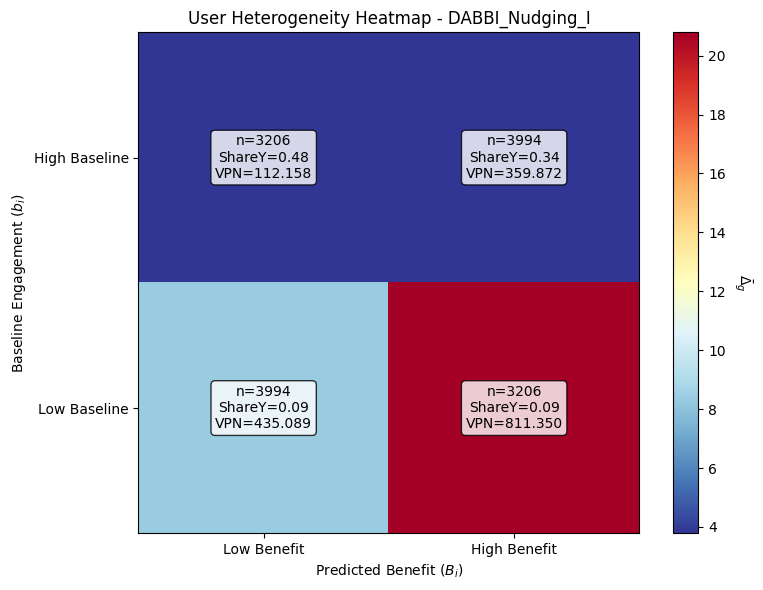

Processing DABBI_Nudging_II...


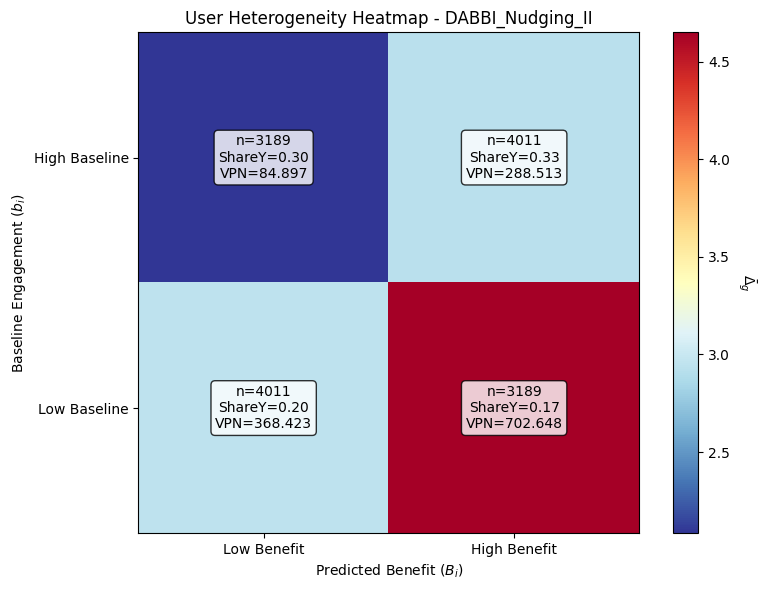

Processing UCB_UniformNudge...


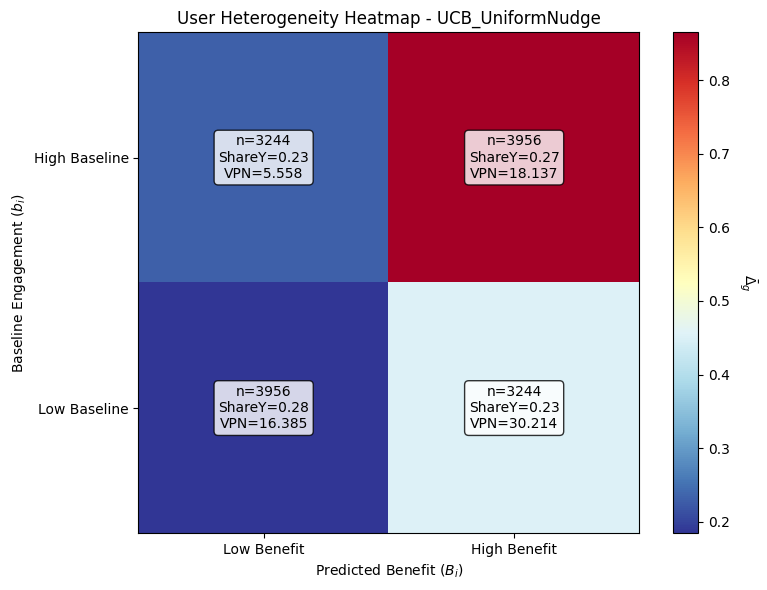

Processing UCB_NoNudge...


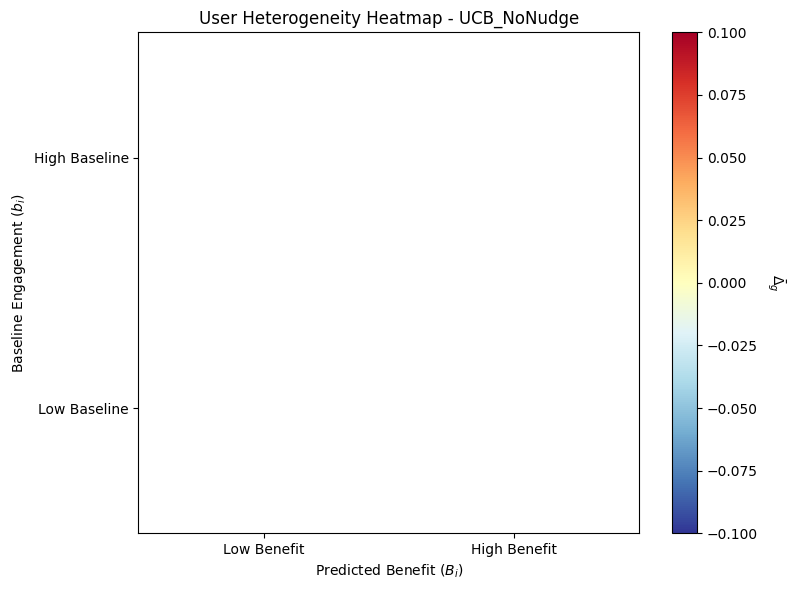

Processing UCB_NoReveal...


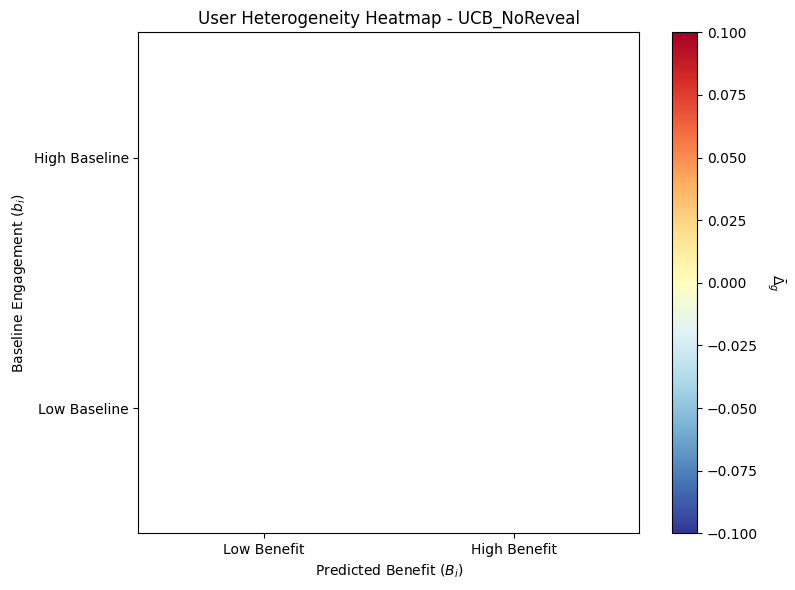

In [37]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_user_heterogeneity(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    user_heterogeneity = metrics.get('user_heterogeneity', None)
    if user_heterogeneity is None:
        raise ValueError(f"Missing 'user_heterogeneity' in {metrics_path}")
    
    return user_heterogeneity

def create_heterogeneity_heatmap(user_heterogeneity, algorithm_name):
    """
    Create 2x2 heatmap: baseline (low/high) vs predicted benefit (low/high)
    """
    classification = user_heterogeneity['classification']
    cell_summaries = classification['cell_summaries']
    
    # Create 2x2 grid
    heatmap_data = np.full((2, 2), np.nan)
    annotations = np.full((2, 2), '', dtype=object)
    
    # Map cell names to grid positions
    cell_to_pos = {
        'LB/LB': (0, 0),  # Low baseline, Low benefit
        'LB/HB': (0, 1),  # Low baseline, High benefit  
        'HB/LB': (1, 0),  # High baseline, Low benefit
        'HB/HB': (1, 1)   # High baseline, High benefit
    }
    
    # Fill heatmap data
    for _, row in cell_summaries.iterrows():
        cell = row['cell']
        if cell in cell_to_pos:
            i, j = cell_to_pos[cell]
            
            # Use mean_delta_g if available, otherwise mean_vpn_g
            # if not np.isnan(row['mean_delta_g']):
            heatmap_data[i, j] = row['mean_delta_g']
            color_label = r'$\bar{\Delta}_g$'
            # else:
            #     heatmap_data[i, j] = row['mean_vpn_g']
            #     color_label = r'$\overline{VPN}_g$'
            
            # Create annotation: n_g, ShareY_g, VPN_g
            n_g = int(row['n_g'])
            share_y = row['share_y_g']
            vpn_g = row['mean_vpn_g']
            
            annotations[i, j] = f'n={n_g}\nShareY={share_y:.2f}\nVPN={vpn_g:.3f}'
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create heatmap
    im = ax.imshow(heatmap_data, cmap='RdYlBu_r', aspect='equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'$\bar{\Delta}_g$', rotation=270, labelpad=20)
    
    # Set ticks and labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Low Benefit', 'High Benefit'])
    ax.set_yticklabels(['High Baseline', 'Low Baseline'])
    ax.set_xlabel('Predicted Benefit ($B_i$)')
    ax.set_ylabel('Baseline Engagement ($b_i$)')
    
    # Add annotations
    for i in range(2):
        for j in range(2):
            if not np.isnan(heatmap_data[i, j]):
                ax.text(j, i, annotations[i, j], ha='center', va='center', 
                       fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_title(f'User Heterogeneity Heatmap - {algorithm_name}')
    plt.tight_layout()
    plt.show()

# Plot heatmap for each algorithm
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    user_heterogeneity = load_user_heterogeneity(metrics_path)
    create_heterogeneity_heatmap(user_heterogeneity, alg)